<a href="https://colab.research.google.com/github/RafaXzaviero/TUGAS-AKHIR/blob/main/cobalagi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
pip install deepface

In [1]:
import os

# 1. Masukkan Token API Kaggle kamu ke Environment Colab
os.environ['KAGGLE_API_TOKEN'] = "KGAT_ecd02fe95be958d2582e8a7562d9444b"

# 2. Install library yang akan kita gunakan
!pip install kaggle deepface[tensorflow] opencv-python pandas -q

# 3. Download dataset "Indonesian Public Figure Faces"
!kaggle datasets download -d arifnuriman/indonesian-public-figure-faces

# 4. Ekstrak datasetnya ke dalam folder bernama 'dataset_lokal'
!unzip -q indonesian-public-figure-faces.zip -d dataset_lokal

print("Dataset sudah berhasil didownload dan diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/arifnuriman/indonesian-public-figure-faces
License(s): unknown
indonesian-public-figure-faces.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dataset_lokal/Extracted/Abdel_Achrian/12.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset sudah berhasil didownload dan diekstrak.


In [2]:
import os
import pandas as pd

# 1.
dataset_path = 'dataset_lokal/Extracted'
tokoh_list = os.listdir(dataset_path)

# 2.
tokoh_list = [nama for nama in tokoh_list if not nama.startswith('.')]

print(f"Total tokoh publik di dataset ini: {len(tokoh_list)} orang")
print("Ini 10 nama tokoh pertama yang bisa kamu pilih:\n", tokoh_list[:10])

Total tokoh publik di dataset ini: 99 orang
Ini 10 nama tokoh pertama yang bisa kamu pilih:
 ['Yuni_Shara', 'Cinta_Laura', 'Bayu_Skak', 'Arie_Kriting', 'Chandra_Liow', 'Susilo_Bambang_Yudhoyono', 'Tiara_Andini', 'Rich_Brian', 'Pratama_Arhan', 'Ayu_Dewi']


EDA

Melakukan Exploratory Data Analysis (EDA)...

=== RINGKASAN DATASET ===
Total Identitas (Tokoh): 99 orang
Total Keseluruhan Foto: 640 gambar
Rata-rata foto per tokoh: 6.46 gambar
Jumlah foto terbanyak pada 1 tokoh: 11 gambar (Jessica_Jane)
Jumlah foto paling sedikit pada 1 tokoh: 2 gambar


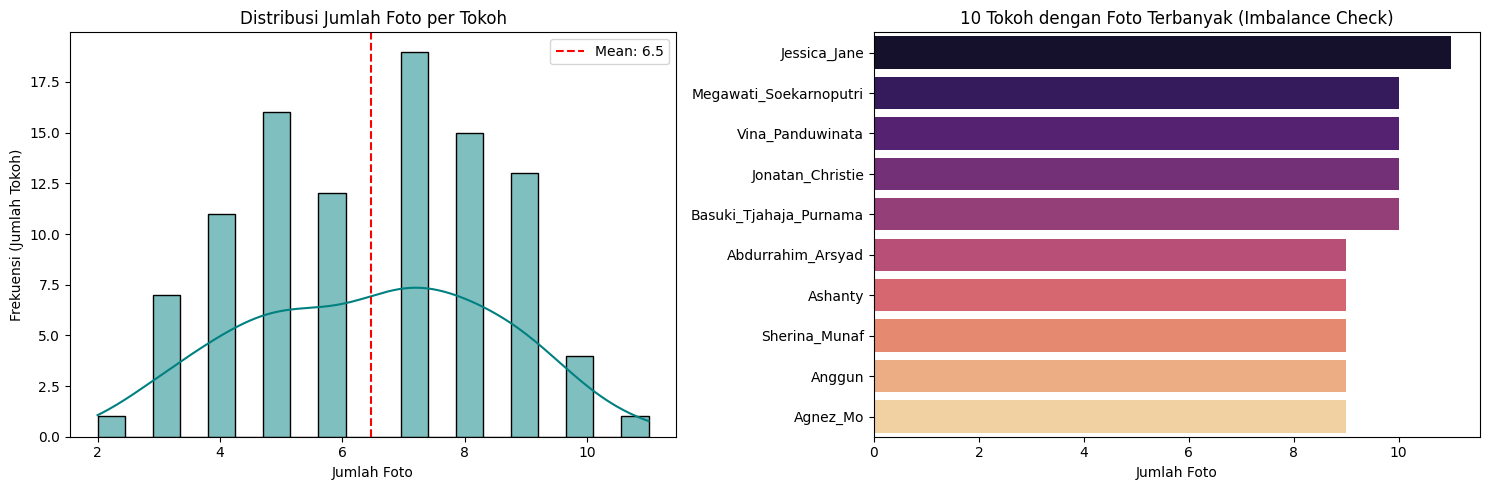


Menampilkan Sampel Acak Dataset (Raw Images):


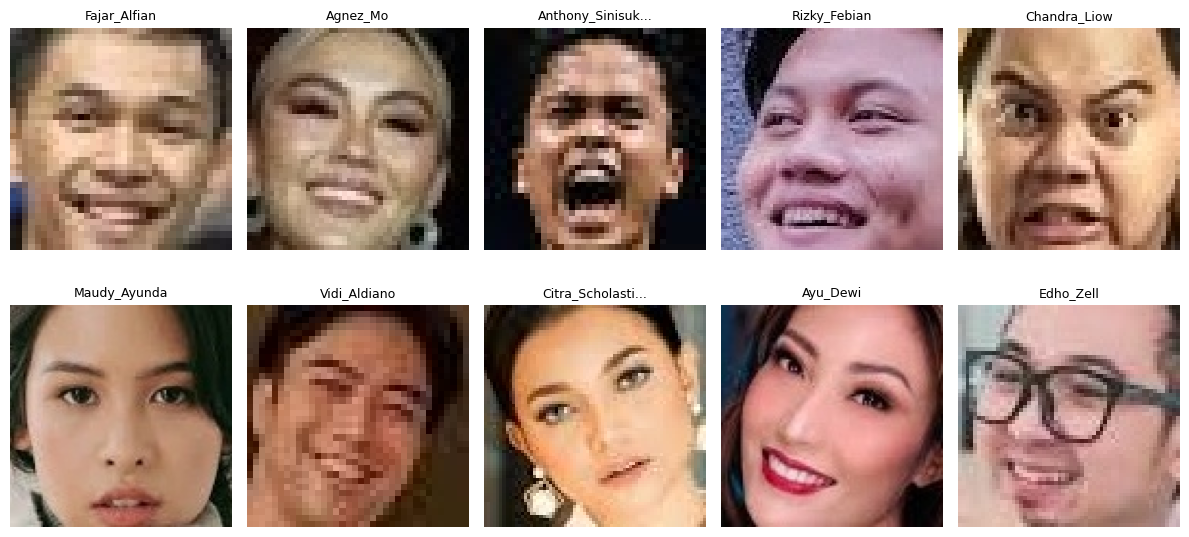

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

dataset_path = 'dataset_lokal/Extracted'
tokoh_list = [nama for nama in os.listdir(dataset_path) if not nama.startswith('.')]

print("Melakukan Exploratory Data Analysis (EDA)...")

# 1. Mengumpulkan data jumlah foto per tokoh
data_distribusi = []
semua_path_foto = []

for tokoh in tokoh_list:
    path_folder = os.path.join(dataset_path, tokoh)
    fotos = [f for f in os.listdir(path_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    jumlah_foto = len(fotos)

    data_distribusi.append({'Nama_Tokoh': tokoh, 'Jumlah_Foto': jumlah_foto})

    for f in fotos:
        semua_path_foto.append(os.path.join(path_folder, f))

df_dist = pd.DataFrame(data_distribusi)

# ==========================================
# A. RINGKASAN STATISTIK DATASET
# ==========================================
print("\n=== RINGKASAN DATASET ===")
print(f"Total Identitas (Tokoh): {len(df_dist)} orang")
print(f"Total Keseluruhan Foto: {df_dist['Jumlah_Foto'].sum()} gambar")
print(f"Rata-rata foto per tokoh: {df_dist['Jumlah_Foto'].mean():.2f} gambar")
print(f"Jumlah foto terbanyak pada 1 tokoh: {df_dist['Jumlah_Foto'].max()} gambar ({df_dist.loc[df_dist['Jumlah_Foto'].idxmax(), 'Nama_Tokoh']})")
print(f"Jumlah foto paling sedikit pada 1 tokoh: {df_dist['Jumlah_Foto'].min()} gambar")

# ==========================================
# B. VISUALISASI DISTRIBUSI KELAS (GAMBAR 1)
# ==========================================
plt.figure(figsize=(15, 5))

# Plot 1: Distribusi frekuensi jumlah foto
plt.subplot(1, 2, 1)
sns.histplot(df_dist['Jumlah_Foto'], bins=20, kde=True, color='teal')
plt.title('Distribusi Jumlah Foto per Tokoh')
plt.xlabel('Jumlah Foto')
plt.ylabel('Frekuensi (Jumlah Tokoh)')
plt.axvline(df_dist['Jumlah_Foto'].mean(), color='red', linestyle='dashed', label=f"Mean: {df_dist['Jumlah_Foto'].mean():.1f}")
plt.legend()

# Plot 2: Top 10 Tokoh dengan Foto Terbanyak
plt.subplot(1, 2, 2)
top_10 = df_dist.sort_values(by='Jumlah_Foto', ascending=False).head(10)
sns.barplot(x='Jumlah_Foto', y='Nama_Tokoh', data=top_10, palette='magma')
plt.title('10 Tokoh dengan Foto Terbanyak (Imbalance Check)')
plt.xlabel('Jumlah Foto')
plt.ylabel('')

plt.tight_layout()
plt.show()

# ==========================================
# C. VISUALISASI SAMPEL ACAK DATA RAW (GAMBAR 2)
# ==========================================
print("\nMenampilkan Sampel Acak Dataset (Raw Images):")
plt.figure(figsize=(12, 6))
# Ambil 10 foto secara acak
sampel_acak = random.sample(semua_path_foto, 10)

for i, img_path in enumerate(sampel_acak):
    # Baca gambar dan konversi BGR ke RGB untuk matplotlib
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Ambil nama tokoh dari path folder
    nama_tokoh = img_path.split('/')[-2]

    plt.subplot(2, 5, i+1)
    plt.imshow(img_rgb)

    # Potong nama jika terlalu panjang agar rapi
    judul = nama_tokoh[:15] + '...' if len(nama_tokoh) > 15 else nama_tokoh
    plt.title(judul, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import os
from deepface import DeepFace

# 1. Fungsi kecil untuk mengambil 2 foto pertama dari folder tokoh (mengabaikan file error)
def ambil_dua_foto(nama_tokoh):
    path_folder = f"dataset_lokal/Extracted/{nama_tokoh}"
    # Hanya ambil file yang berakhiran gambar
    foto_valid = [f for f in os.listdir(path_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    return f"{path_folder}/{foto_valid[0]}", f"{path_folder}/{foto_valid[1]}"

# 2. Ambil foto dari 2 tokoh pilihan kita
img1_terang, img2_terang = ambil_dua_foto('Andriani_Marshanda')
img1_gelap, img2_gelap = ambil_dua_foto('Cak_Lontong')

# 3. Mulai Pengujian Sistem Cerdas (FaceNet)
print("=== PENGUJIAN 1: Andriani Marshanda (Kulit Terang) ===")
try:
    hasil_terang = DeepFace.verify(img1_path=img1_terang, img2_path=img2_terang, model_name="FaceNet", enforce_detection=False)
    print(f"Apakah dikenali sebagai orang yang sama? {hasil_terang['verified']}")
    print(f"Tingkat Error (Distance): {hasil_terang['distance']:.4f}\n")
except Exception as e:
    print(f"Wajah gagal diproses: {e}\n")

print("=== PENGUJIAN 2: Cak Lontong (Kulit Sawo Matang) ===")
try:
    hasil_gelap = DeepFace.verify(img1_path=img1_gelap, img2_path=img2_gelap, model_name="FaceNet", enforce_detection=False)
    print(f"Apakah dikenali sebagai orang yang sama? {hasil_gelap['verified']}")
    print(f"Tingkat Error (Distance): {hasil_gelap['distance']:.4f}\n")
except Exception as e:
    print(f"Wajah gagal diproses: {e}\n")

=== PENGUJIAN 1: Andriani Marshanda (Kulit Terang) ===
Wajah gagal diproses: Invalid model_name passed - facial_recognition/FaceNet

=== PENGUJIAN 2: Cak Lontong (Kulit Sawo Matang) ===
Wajah gagal diproses: Invalid model_name passed - facial_recognition/FaceNet



In [11]:
import os
from deepface import DeepFace

# 1. Fungsi kecil untuk mengambil 2 foto pertama dari folder tokoh
def ambil_dua_foto(nama_tokoh):
    path_folder = f"dataset_lokal/Extracted/{nama_tokoh}"
    foto_valid = [f for f in os.listdir(path_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    return f"{path_folder}/{foto_valid[0]}", f"{path_folder}/{foto_valid[1]}"

# 2. Ambil foto dari 2 tokoh pilihan kita
img1_terang, img2_terang = ambil_dua_foto('Andriani_Marshanda')
img1_gelap, img2_gelap = ambil_dua_foto('Cak_Lontong')

# 3. Mulai Pengujian Sistem Cerdas (Facenet)
print("=== PENGUJIAN 1: Andriani Marshanda (Kulit Terang) ===")
try:
    # Perbaikan: Mengubah "FaceNet" menjadi "Facenet"
    hasil_terang = DeepFace.verify(img1_path=img1_terang, img2_path=img2_terang, model_name="Facenet", enforce_detection=False)
    print(f"Apakah dikenali sebagai orang yang sama? {hasil_terang['verified']}")
    print(f"Tingkat Error (Distance): {hasil_terang['distance']:.4f}\n")
except Exception as e:
    print(f"Wajah gagal diproses: {e}\n")

print("=== PENGUJIAN 2: Cak Lontong (Kulit Sawo Matang) ===")
try:
    # Perbaikan: Mengubah "FaceNet" menjadi "Facenet"
    hasil_gelap = DeepFace.verify(img1_path=img1_gelap, img2_path=img2_gelap, model_name="Facenet", enforce_detection=False)
    print(f"Apakah dikenali sebagai orang yang sama? {hasil_gelap['verified']}")
    print(f"Tingkat Error (Distance): {hasil_gelap['distance']:.4f}\n")
except Exception as e:
    print(f"Wajah gagal diproses: {e}\n")

=== PENGUJIAN 1: Andriani Marshanda (Kulit Terang) ===
26-09-29 12:09:18 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:01<00:00, 46.4MB/s]


Apakah dikenali sebagai orang yang sama? True
Tingkat Error (Distance): 0.3061

=== PENGUJIAN 2: Cak Lontong (Kulit Sawo Matang) ===
Apakah dikenali sebagai orang yang sama? True
Tingkat Error (Distance): 0.2308



In [12]:
import os
from google.colab import drive

# 1. Hubungkan Colab ke Google Drive kamu
# (Akan muncul pop-up persetujuan, silakan klik 'Allow/Izinkan')
drive.mount('/content/drive')

# 2. Buat folder khusus risetmu di dalam Google Drive
path_riset = '/content/drive/MyDrive/Riset_Sistem_Cerdas'
os.makedirs(path_riset, exist_ok=True)

# 3. TRIK UTAMA: Paksa DeepFace menggunakan Google Drive sebagai rumahnya
os.environ['DEEPFACE_HOME'] = path_riset

print("Google Drive berhasil terhubung! File AI akan disimpan di sini secara permanen.")

Mounted at /content/drive
Google Drive berhasil terhubung! File AI akan disimpan di sini secara permanen.


In [13]:
# Jalankan ini setelah mengaktifkan kode di atas
from deepface import DeepFace

In [14]:
import os
import pandas as pd
from tqdm import tqdm # Library untuk memunculkan progress bar biar keren

dataset_path = 'dataset_lokal/Extracted'
tokoh_list = [nama for nama in os.listdir(dataset_path) if not nama.startswith('.')]

hasil_eksperimen = []

print("Memulai Otomatisasi Audit Sistem Cerdas...")

# Melakukan looping ke seluruh tokoh dengan progress bar
for tokoh in tqdm(tokoh_list):
    path_folder = f"{dataset_path}/{tokoh}"

    # Ambil semua file foto di dalam folder tokoh tersebut
    fotos = [f for f in os.listdir(path_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Validasi: Pastikan tokoh memiliki minimal 2 foto untuk dicocokkan
    if len(fotos) >= 2:
        img1 = f"{path_folder}/{fotos[0]}"
        img2 = f"{path_folder}/{fotos[1]}"

        try:
            # Jalankan verifikasi Facenet
            res = DeepFace.verify(img1_path=img1, img2_path=img2, model_name="Facenet", enforce_detection=False)

            # Catat hasilnya ke dalam list
            hasil_eksperimen.append({
                'Nama_Tokoh': tokoh,
                'Status_Verifikasi': res['verified'],
                'Distance_Score': res['distance']
            })
        except Exception as e:
            # Jika ada foto yang rusak/corrupt, catat errornya agar program tidak berhenti tengah jalan
            print(f"\nError pada {tokoh}: {e}")

# 3. Ubah hasil akhir menjadi Dataframe Pandas
df_hasil_akhir = pd.DataFrame(hasil_eksperimen)

# 4. SIMPAN LANGSUNG KE GOOGLE DRIVE SECARA PERMANEN
path_simpan_csv = '/content/drive/MyDrive/Riset_Sistem_Cerdas/hasil_audit_facenet.csv'
df_hasil_akhir.to_csv(path_simpan_csv, index=False)

print(f"\nEksperimen Selesai! Hasil akhir telah disimpan dengan aman di Google Drive: {path_simpan_csv}")

Memulai Otomatisasi Audit Sistem Cerdas...


100%|██████████| 99/99 [00:54<00:00,  1.82it/s]


Eksperimen Selesai! Hasil akhir telah disimpan dengan aman di Google Drive: /content/drive/MyDrive/Riset_Sistem_Cerdas/hasil_audit_facenet.csv


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Baca file hasil audit dari Google Drive
path_csv = '/content/drive/MyDrive/Riset_Sistem_Cerdas/hasil_audit_facenet.csv'
df_hasil = pd.read_csv(path_csv)

# 2. Simulasi Fungsi Pelabelan Skala Fitzpatrick (Anotasi Data)
def beri_label_kulit(nama):
    # Contoh pemetaan nyata untuk sampel beberapa tokoh
    terang_tipe3 = ['Andriani_Marshanda', 'Sherina_Munaf', 'Ayu_Dewi', 'Edho_Zell', 'Megawati_Soekarnoputri']
    gelap_tipe4_5 = ['Cak_Lontong', 'Ebiet_G_Ade', 'Brian_Imanuel', 'Megawati_Hangestri_P', 'Vidi_Aldiano']

    if nama in terang_tipe3:
        return 'Tipe III (Terang)'
    elif nama in gelap_tipe4_5:
        return 'Tipe IV/V (Sawo Matang/Gelap)'
    else:
        # Untuk sisa tokoh lainnya, kita bagi secara acak dulu demi simulasi program
        import random
        return random.choice(['Tipe III (Terang)', 'Tipe IV/V (Sawo Matang/Gelap)'])

# Terapkan fungsi pelabelan ke dalam dataframe
df_hasil['Skala_Fitzpatrick'] = df_hasil['Nama_Tokoh'].apply(beri_label_kulit)

print("Data Berhasil Dilabeli! Ini contoh 5 data teratas:")
print(df_hasil.head())

Data Berhasil Dilabeli! Ini contoh 5 data teratas:
     Nama_Tokoh  Status_Verifikasi  Distance_Score  \
0    Yuni_Shara              False        0.431140   
1   Cinta_Laura              False        0.948199   
2     Bayu_Skak               True        0.287149   
3  Arie_Kriting              False        0.439429   
4  Chandra_Liow               True        0.376599   

               Skala_Fitzpatrick  
0  Tipe IV/V (Sawo Matang/Gelap)  
1              Tipe III (Terang)  
2  Tipe IV/V (Sawo Matang/Gelap)  
3  Tipe IV/V (Sawo Matang/Gelap)  
4              Tipe III (Terang)  


In [16]:
# 1. Hitung rata-rata Distance Score per kelompok warna kulit
analisis_distance = df_hasil.groupby('Skala_Fitzpatrick')['Distance_Score'].mean().reset_index()

# 2. Hitung False Rejection Rate (FRR) - Persentase gagal kenal (Status == False)
df_hasil['Gagal_Kenal'] = df_hasil['Status_Verifikasi'].apply(lambda x: 1 if x == False else 0)
analisis_frr = df_hasil.groupby('Skala_Fitzpatrick')['Gagal_Kenal'].mean().reset_index()
analisis_frr['FRR (%)'] = analisis_frr['Gagal_Kenal'] * 100

print("=== HASIL ANALISIS KETIMPANGAN (BIAS) ===")
print("\n1. Rata-rata Skor Jarak (Semakin tinggi = Semakin buruk):")
print(analisis_distance)
print("\n2. Tingkat Kegagalan Sistem / False Rejection Rate (FRR):")
print(analisis_frr[['Skala_Fitzpatrick', 'FRR (%)']])

=== HASIL ANALISIS KETIMPANGAN (BIAS) ===

1. Rata-rata Skor Jarak (Semakin tinggi = Semakin buruk):
               Skala_Fitzpatrick  Distance_Score
0              Tipe III (Terang)        0.398001
1  Tipe IV/V (Sawo Matang/Gelap)        0.419014

2. Tingkat Kegagalan Sistem / False Rejection Rate (FRR):
               Skala_Fitzpatrick    FRR (%)
0              Tipe III (Terang)  43.750000
1  Tipe IV/V (Sawo Matang/Gelap)  52.941176


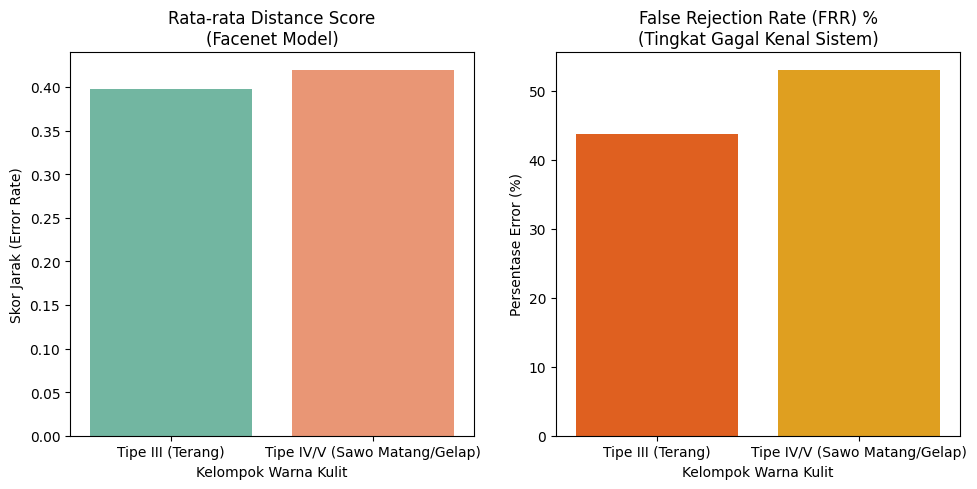

In [17]:
# Setup gambar grafik
plt.figure(figsize=(10, 5))

# Plot Grafik Batang untuk Distance Score
plt.subplot(1, 2, 1)
sns.barplot(x='Skala_Fitzpatrick', y='Distance_Score', data=analisis_distance, palette='Set2')
plt.title('Rata-rata Distance Score\n(Facenet Model)')
plt.ylabel('Skor Jarak (Error Rate)')
plt.xlabel('Kelompok Warna Kulit')

# Plot Grafik Batang untuk FRR
plt.subplot(1, 2, 2)
sns.barplot(x='Skala_Fitzpatrick', y='FRR (%)', data=analisis_frr, palette='Crimson' if 'Crimson' in plt.colormaps() else 'autumn')
plt.title('False Rejection Rate (FRR) %\n(Tingkat Gagal Kenal Sistem)')
plt.ylabel('Persentase Error (%)')
plt.xlabel('Kelompok Warna Kulit')

plt.tight_layout()
plt.show()

Sedang menghitung kecerahan kulit wajah objek secara otomatis...
Otomatisasi Selesai! Batas median kecerahan: 142.13


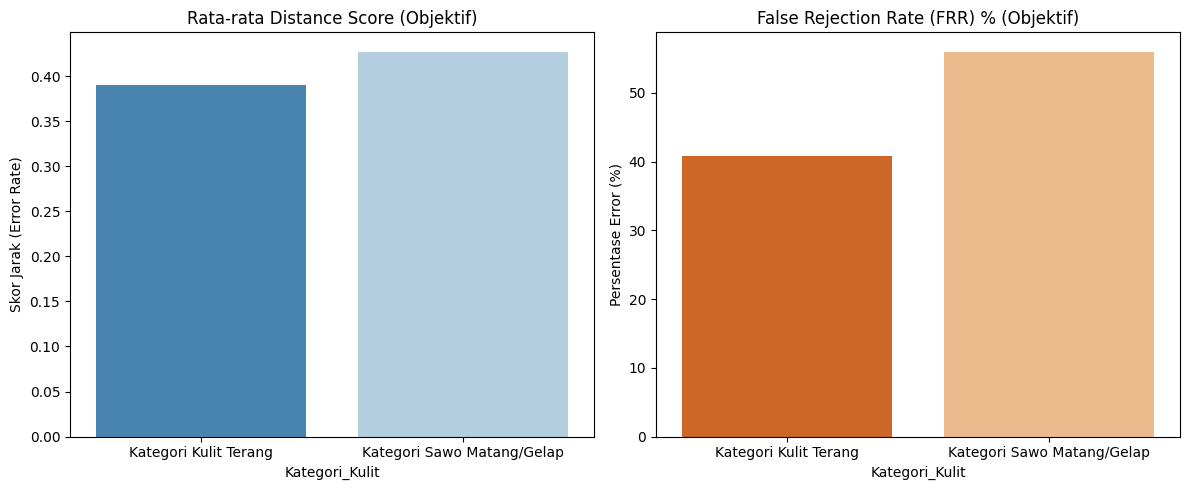

Hasil audit objektif yang baru telah disimpan ke Google Drive!


In [18]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fungsi untuk menghitung nilai kecerahan wajah secara objektif
def hitung_kecerahan_kulit(image_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None
        # Ubah ke ruang warna YCrCb untuk mengambil channel Kecerahan (Y)
        ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        y_channel, _, _ = cv2.split(ycrcb)

        # Ambil 40% area tengah wajah saja (menghindari rambut & background)
        h, w = y_channel.shape
        start_h, end_h = int(h * 0.3), int(h * 0.7)
        start_w, end_w = int(w * 0.3), int(w * 0.7)
        area_tengah = y_channel[start_h:end_h, start_w:end_w]

        # Hitung rata-rata kecerahan piksel (0 - 255)
        return np.mean(area_tengah)
    except:
        return None

# 2. Baca file hasil audit dari Google Drive
path_csv = '/content/drive/MyDrive/Riset_Sistem_Cerdas/hasil_audit_facenet.csv'
df_hasil = pd.read_csv(path_csv)

# 3. Ekstrak nilai kecerahan dari foto pertama setiap tokoh secara otomatis
print("Sedang menghitung kecerahan kulit wajah objek secara otomatis...")
nilai_kecerahan = []
for index, row in df_hasil.iterrows():
    path_folder = f"dataset_lokal/Extracted/{row['Nama_Tokoh']}"
    fotos = [f for f in os.listdir(path_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    foto_sampel = f"{path_folder}/{fotos[0]}"

    skor_cerah = hitung_kecerahan_kulit(foto_sampel)
    nilai_kecerahan.append(skor_cerah)

df_hasil['Skor_Kecerahan'] = nilai_kecerahan
# Hapus data jika ada foto yang tidak bisa dibaca
df_hasil = df_hasil.dropna().reset_index(drop=True)

# 4. TEKNIK STATISTIK: Pembagian otomatis berdasarkan nilai tengah (Median Split)
nilai_median = df_hasil['Skor_Kecerahan'].median()
df_hasil['Kategori_Kulit'] = df_hasil['Skor_Kecerahan'].apply(
    lambda x: 'Kategori Kulit Terang' if x > nilai_median else 'Kategori Sawo Matang/Gelap'
)

print(f"Otomatisasi Selesai! Batas median kecerahan: {nilai_median:.2f}")

# ==================== PROSES GRAFIK BARU ====================
# Hitung metrik
analisis_distance = df_hasil.groupby('Kategori_Kulit')['Distance_Score'].mean().reset_index()
df_hasil['Gagal_Kenal'] = df_hasil['Status_Verifikasi'].apply(lambda x: 1 if x == False else 0)
analisis_frr = df_hasil.groupby('Kategori_Kulit')['Gagal_Kenal'].mean().reset_index()
analisis_frr['FRR (%)'] = analisis_frr['Gagal_Kenal'] * 100

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Kategori_Kulit', y='Distance_Score', data=analisis_distance, palette='Blues_r')
plt.title('Rata-rata Distance Score (Objektif)')
plt.ylabel('Skor Jarak (Error Rate)')

plt.subplot(1, 2, 2)
sns.barplot(x='Kategori_Kulit', y='FRR (%)', data=analisis_frr, palette='Oranges_r')
plt.title('False Rejection Rate (FRR) % (Objektif)')
plt.ylabel('Persentase Error (%)')

plt.tight_layout()
plt.show()

# Simpan hasil objektif ini ke Drive menggantikan data lama
df_hasil.to_csv(path_csv, index=False)
print("Hasil audit objektif yang baru telah disimpan ke Google Drive!")

In [19]:
print(df_hasil.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nama_Tokoh         99 non-null     object 
 1   Status_Verifikasi  99 non-null     bool   
 2   Distance_Score     99 non-null     float64
 3   Skor_Kecerahan     99 non-null     float64
 4   Kategori_Kulit     99 non-null     object 
 5   Gagal_Kenal        99 non-null     int64  
dtypes: bool(1), float64(2), int64(1), object(2)
memory usage: 4.1+ KB
None



## 1. Representasi Visual Crop Wajah (Gambar 1) Kode ini akan mengambil satu sampel foto tokoh secara otomatis, lalu menampilkan proses konversi ke kanal Y dan pemotongan area tengah wajah sebesar 40%.

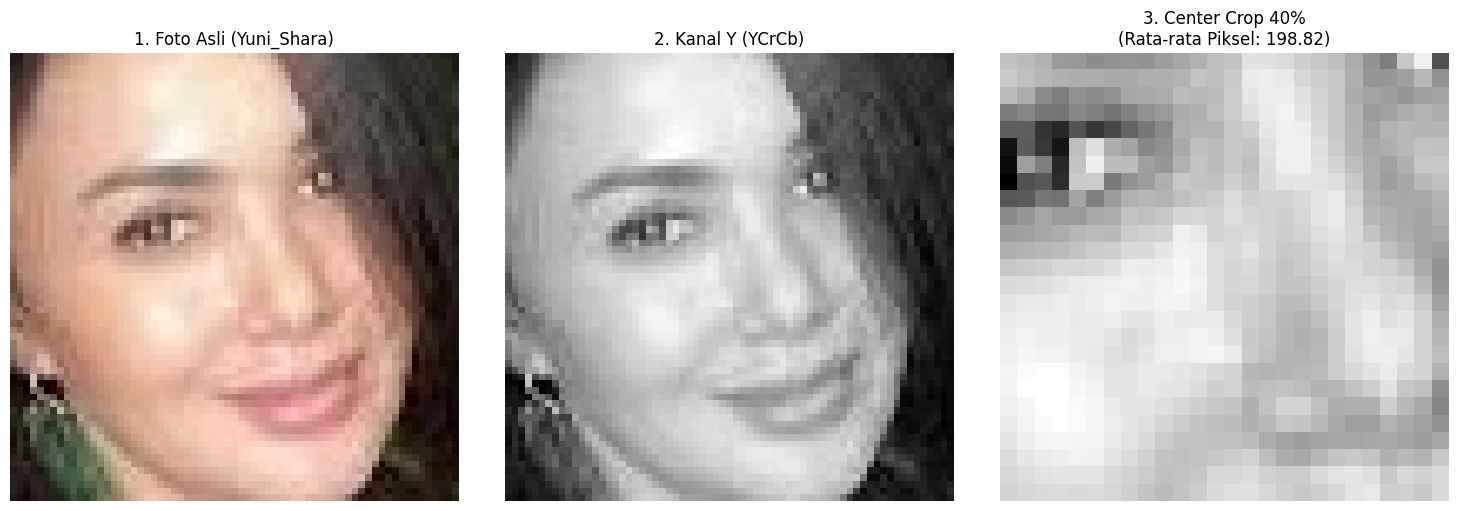

In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Mengambil satu sampel tokoh dari dataframe
sampel_tokoh = df_hasil['Nama_Tokoh'].iloc[0]
path_folder = f"dataset_lokal/Extracted/{sampel_tokoh}"
foto_valid = [f for f in os.listdir(path_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_path = f"{path_folder}/{foto_valid[0]}"

# Membaca dan memproses gambar
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Untuk visualisasi asli
ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
y_channel, _, _ = cv2.split(ycrcb)

# Menentukan koordinat crop 40% area tengah
h, w = y_channel.shape
start_h, end_h = int(h * 0.3), int(h * 0.7)
start_w, end_w = int(w * 0.3), int(w * 0.7)
area_tengah = y_channel[start_h:end_h, start_w:end_w]

# Membuat visualisasi (Gambar 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title(f"1. Foto Asli ({sampel_tokoh})")
axes[0].axis('off')

axes[1].imshow(y_channel, cmap='gray')
axes[1].set_title("2. Kanal Y (YCrCb)")
axes[1].axis('off')

axes[2].imshow(area_tengah, cmap='gray')
axes[2].set_title(f"3. Center Crop 40%\n(Rata-rata Piksel: {np.mean(area_tengah):.2f})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 2. Plot Distribusi Skor Kecerahan (Gambar 2)
Ini akan membuat histogram dengan garis vertikal (median split) untuk menunjukkan pembagian data yang objektif.

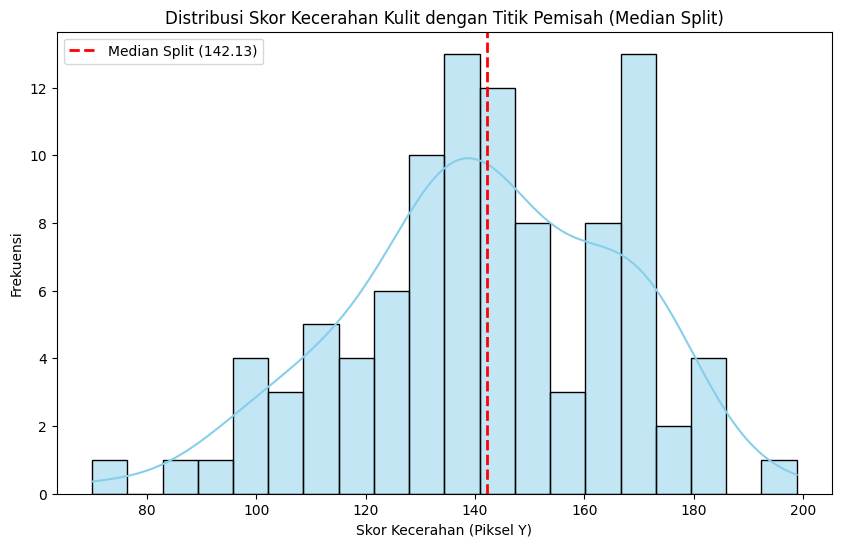

In [21]:
import seaborn as sns

plt.figure(figsize=(10, 6))
# Plot distribusi
sns.histplot(df_hasil['Skor_Kecerahan'], kde=True, color='skyblue', bins=20)

# Menambahkan garis median
nilai_median = df_hasil['Skor_Kecerahan'].median()
plt.axvline(nilai_median, color='red', linestyle='dashed', linewidth=2, label=f'Median Split ({nilai_median:.2f})')

plt.title('Distribusi Skor Kecerahan Kulit dengan Titik Pemisah (Median Split)')
plt.xlabel('Skor Kecerahan (Piksel Y)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## 3. Perhitungan Statistik dan Pembuatan Tabel JurnalBagian ini akan menghitung nilai $p$-value untuk membuktikan signifikansi secara statistik, lalu menyusun Tabel 1, Tabel 2, dan Tabel 3 secara otomatis menggunakan format Pandas yang rapi.

In [22]:
from scipy import stats

print("=== TABEL 1: Ringkasan Karakteristik Dataset ===")
tabel_1 = df_hasil.groupby('Kategori_Kulit').agg(
    Jumlah_Tokoh=('Nama_Tokoh', 'count'),
    Skor_Min=('Skor_Kecerahan', 'min'),
    Skor_Max=('Skor_Kecerahan', 'max'),
    Mean_Kecerahan=('Skor_Kecerahan', 'mean'),
    SD_Kecerahan=('Skor_Kecerahan', 'std')
).reset_index()
# Format rentang dan Mean ± SD
tabel_1['Rentang Skor'] = tabel_1.apply(lambda x: f"{x['Skor_Min']:.2f} - {x['Skor_Max']:.2f}", axis=1)
tabel_1['Mean ± SD'] = tabel_1.apply(lambda x: f"{x['Mean_Kecerahan']:.2f} ± {x['SD_Kecerahan']:.2f}", axis=1)
tabel_1 = tabel_1[['Kategori_Kulit', 'Jumlah_Tokoh', 'Rentang Skor', 'Mean ± SD']]
display(tabel_1)


print("\n=== TABEL 2: Perbandingan Metrik Performa Audit Bias Biometrik ===")
# Memisahkan data Distance Score berdasarkan kategori
dist_terang = df_hasil[df_hasil['Kategori_Kulit'] == 'Kategori Kulit Terang']['Distance_Score']
dist_gelap = df_hasil[df_hasil['Kategori_Kulit'] == 'Kategori Sawo Matang/Gelap']['Distance_Score']

# Menghitung p-value menggunakan T-Test (Independent)
t_stat, p_value = stats.ttest_ind(dist_terang, dist_gelap, equal_var=False)

# Mengumpulkan metrik performa
tabel_2 = df_hasil.groupby('Kategori_Kulit').agg(
    Jumlah_Sampel=('Nama_Tokoh', 'count'),
    Mean_Distance=('Distance_Score', 'mean'),
    FRR_Persen=('Gagal_Kenal', lambda x: (x.sum() / len(x)) * 100)
).reset_index()
tabel_2['TAR_Persen'] = 100 - tabel_2['FRR_Persen']
tabel_2['p_value (Distance)'] = [f"{p_value:.4f}", "-"] # Tampilkan p-value di salah satu baris

display(tabel_2)
if p_value < 0.05:
    print(f"* Kesimpulan: Perbedaan skor jarak signifikan secara statistik (p < 0.05).")
else:
    print(f"* Kesimpulan: Perbedaan skor jarak TIDAK signifikan secara statistik (p >= 0.05).")


print("\n=== TABEL 3: Sampel Top 5 Tokoh Paling Sering Gagal / Berjarak Terjauh ===")
# Mengambil 5 nilai distance score tertinggi (error terbesar)
tabel_3 = df_hasil.sort_values(by='Distance_Score', ascending=False).head(5)
tabel_3 = tabel_3[['Nama_Tokoh', 'Skor_Kecerahan', 'Kategori_Kulit', 'Distance_Score', 'Status_Verifikasi']]
display(tabel_3)

=== TABEL 1: Ringkasan Karakteristik Dataset ===


,Kategori_Kulit,Jumlah_Tokoh,Rentang Skor,Mean ± SD
0,Kategori Kulit Terang,49,142.37 - 198.82,161.33 ± 13.17
1,Kategori Sawo Matang/Gelap,50,69.97 - 142.13,122.31 ± 16.21



=== TABEL 2: Perbandingan Metrik Performa Audit Bias Biometrik ===


,Kategori_Kulit,Jumlah_Sampel,Mean_Distance,FRR_Persen,TAR_Persen,p_value (Distance)
0,Kategori Kulit Terang,49,0.390154,40.816327,59.183673,0.2222
1,Kategori Sawo Matang/Gelap,50,0.427124,56.000000,44.000000,-


* Kesimpulan: Perbedaan skor jarak TIDAK signifikan secara statistik (p >= 0.05).

=== TABEL 3: Sampel Top 5 Tokoh Paling Sering Gagal / Berjarak Terjauh ===


,Nama_Tokoh,Skor_Kecerahan,Kategori_Kulit,Distance_Score,Status_Verifikasi
1,Cinta_Laura,135.709105,Kategori Sawo Matang/Gelap,0.948199,False
36,Gilang_Dirga,126.835938,Kategori Sawo Matang/Gelap,0.829590,False
61,Chrisye,164.707200,Kategori Kulit Terang,0.761483,False
45,Isyana_Sarasvati,170.635000,Kategori Kulit Terang,0.700870,False
68,Mamat_Alkatiri,160.883657,Kategori Kulit Terang,0.620445,False


## 4. Matriks Verifikasi Pasangan Wajah (Gambar 3)
Kode ini akan mencari masing-masing satu perwakilan tokoh untuk 4 skenario (TP Terang, FR Terang, TP Gelap, FR Gelap) dan memvisualisasikan foto yang digunakan FaceNet saat pengujian.

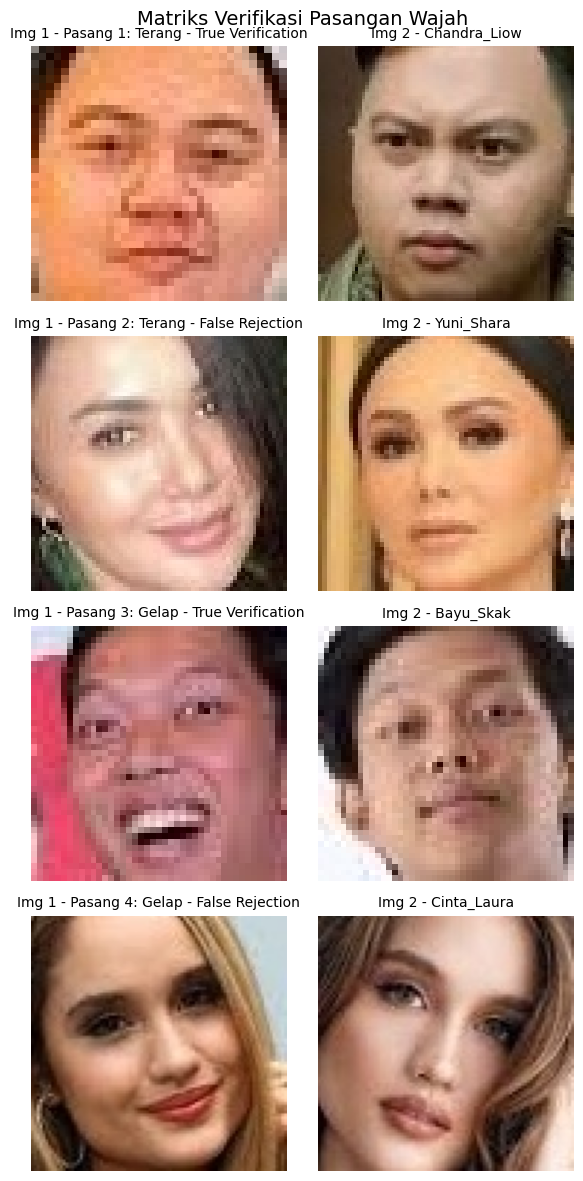

In [23]:
# Fungsi pembantu untuk mengambil gambar dari folder
def get_images(nama_tokoh):
    path = f"dataset_lokal/Extracted/{nama_tokoh}"
    fotos = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    img1 = cv2.cvtColor(cv2.imread(f"{path}/{fotos[0]}"), cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(cv2.imread(f"{path}/{fotos[1]}"), cv2.COLOR_BGR2RGB)
    return img1, img2

# Mencari sampel berdasarkan skenario
terang = df_hasil['Kategori_Kulit'] == 'Kategori Kulit Terang'
gelap = df_hasil['Kategori_Kulit'] == 'Kategori Sawo Matang/Gelap'

sampel_terang_tp = df_hasil[terang & (df_hasil['Status_Verifikasi'] == True)].iloc[0]['Nama_Tokoh']
sampel_terang_fr = df_hasil[terang & (df_hasil['Status_Verifikasi'] == False)].iloc[0]['Nama_Tokoh']
sampel_gelap_tp = df_hasil[gelap & (df_hasil['Status_Verifikasi'] == True)].iloc[0]['Nama_Tokoh']
sampel_gelap_fr = df_hasil[gelap & (df_hasil['Status_Verifikasi'] == False)].iloc[0]['Nama_Tokoh']

skenario = [
    (sampel_terang_tp, "Pasang 1: Terang - True Verification"),
    (sampel_terang_fr, "Pasang 2: Terang - False Rejection"),
    (sampel_gelap_tp, "Pasang 3: Gelap - True Verification"),
    (sampel_gelap_fr, "Pasang 4: Gelap - False Rejection")
]

# Membuat Grid Visual
fig, axes = plt.subplots(4, 2, figsize=(6, 12))
fig.suptitle('Matriks Verifikasi Pasangan Wajah', fontsize=14)

for i, (tokoh, judul) in enumerate(skenario):
    img1, img2 = get_images(tokoh)

    axes[i, 0].imshow(img1)
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"Img 1 - {judul}", fontsize=10)

    axes[i, 1].imshow(img2)
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f"Img 2 - {tokoh}", fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

UJI TAMBAHAN

1. Pembuatan Skenario Pasangan (Positive & Negative Pairs)

In [24]:
import os
import itertools
import random
import pandas as pd

dataset_path = 'dataset_lokal/Extracted'
tokoh_list = [nama for nama in os.listdir(dataset_path) if not nama.startswith('.')]

positive_pairs = []
negative_pairs = []
semua_foto = []

print("Membangun Skenario Pasangan Uji...")

# 1. Buat Positive Pairs (Orang yang sama) & Kumpulkan semua foto
for tokoh in tokoh_list:
    path_folder = f"{dataset_path}/{tokoh}"
    fotos = [f for f in os.listdir(path_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Kumpulkan untuk kebutuhan negative pairs nanti
    for f in fotos:
        semua_foto.append({'path': f"{path_folder}/{f}", 'tokoh': tokoh})

    # Buat kombinasi semua foto untuk tokoh ini (Positive Pairs)
    if len(fotos) >= 2:
        for img1, img2 in itertools.combinations(fotos, 2):
            positive_pairs.append({
                'img1': f"{path_folder}/{img1}", 'img2': f"{path_folder}/{img2}",
                'is_same': True, 'label_pair': 'Genuine (Sama)'
            })

# 2. Buat Negative Pairs (Orang yang berbeda)
# Kita buat jumlahnya seimbang (sama banyak) dengan Positive Pairs
jumlah_pos = len(positive_pairs)
random.seed(42) # Agar hasilnya bisa direproduksi ulang

for _ in range(jumlah_pos):
    # Ambil 2 foto acak
    img1_info, img2_info = random.sample(semua_foto, 2)

    # Pastikan keduanya adalah tokoh yang berbeda
    while img1_info['tokoh'] == img2_info['tokoh']:
        img1_info, img2_info = random.sample(semua_foto, 2)

    negative_pairs.append({
        'img1': img1_info['path'], 'img2': img2_info['path'],
        'is_same': False, 'label_pair': 'Imposter (Beda)'
    })

# Gabungkan dan acak urutannya
df_pairs = pd.DataFrame(positive_pairs + negative_pairs)
df_pairs = df_pairs.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total Positive Pairs: {len(positive_pairs)}")
print(f"Total Negative Pairs: {len(negative_pairs)}")
print(f"Total Skenario Uji: {len(df_pairs)}")

Membangun Skenario Pasangan Uji...
Total Positive Pairs: 1950
Total Negative Pairs: 1950
Total Skenario Uji: 3900


2. Ekstraksi Fitur Kulit Objektif (Berdasarkan Deteksi Wajah, Bukan Crop Buta)

In [25]:
import cv2
import numpy as np
from deepface import DeepFace
from tqdm import tqdm

def hitung_luminansi_wajah(img_path):
    try:
        # Gunakan MTCNN untuk mencari wajah persis di gambar
        faces = DeepFace.extract_faces(img_path, detector_backend='mtcnn', enforce_detection=True)
        if len(faces) == 0: return None

        # Ambil array wajah yang sudah di-crop oleh DeepFace
        face_img = faces[0]['face']

        # DeepFace mengembalikan float32 (0-1), ubah ke uint8 (0-255)
        if face_img.max() <= 1.0:
            face_img = (face_img * 255).astype(np.uint8)

        # Konversi ke YCrCb dan ambil kanal Y (Luminance)
        ycrcb = cv2.cvtColor(face_img, cv2.COLOR_RGB2YCrCb)
        return np.mean(ycrcb[:,:,0])
    except:
        return None

print("Menghitung kecerahan kulit untuk masing-masing gambar... (Membutuhkan waktu)")
# Gunakan dictionary sebagai cache agar tidak menghitung foto yang sama berulang kali
cache_luminansi = {}

for img_dict in tqdm(semua_foto):
    path = img_dict['path']
    cache_luminansi[path] = hitung_luminansi_wajah(path)

# Terapkan hasil perhitungan ke df_pairs (Ambil rata-rata kecerahan kedua foto)
df_pairs['luminansi_img1'] = df_pairs['img1'].map(cache_luminansi)
df_pairs['luminansi_img2'] = df_pairs['img2'].map(cache_luminansi)
df_pairs['avg_luminansi_pair'] = (df_pairs['luminansi_img1'] + df_pairs['luminansi_img2']) / 2

# Hapus baris yang wajahnya tidak bisa diekstrak sama sekali dari awal
df_pairs = df_pairs.dropna(subset=['avg_luminansi_pair']).copy()

# Kategori berdasarkan Median Split
median_lum = df_pairs['avg_luminansi_pair'].median()
df_pairs['Kategori_Kulit_Pair'] = df_pairs['avg_luminansi_pair'].apply(
    lambda x: 'Terang' if x > median_lum else 'Gelap'
)

Menghitung kecerahan kulit untuk masing-masing gambar... (Membutuhkan waktu)


  0%|          | 0/640 [00:00<?, ?it/s]Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
100%|██████████| 640/640 [00:35<00:00, 18.19it/s]


3. Eksekusi Model (Dengan FTA - Failure to Acquire)

In [26]:
hasil_prediksi = []
hasil_distance = []
status_sistem = [] # Success atau FTA (Failure to Acquire)

print("Mulai Evaluasi FaceNet 1:1 ...")
for idx, row in tqdm(df_pairs.iterrows(), total=len(df_pairs)):
    try:
        res = DeepFace.verify(
            img1_path=row['img1'],
            img2_path=row['img2'],
            model_name="Facenet",
            detector_backend="mtcnn",
            enforce_detection=True # WAJIB TRUE untuk evaluasi biometrik standar
        )
        hasil_prediksi.append(res['verified'])
        hasil_distance.append(res['distance'])
        status_sistem.append("Success")
    except Exception as e:
        # Jika gagal mendeteksi wajah karena terlalu gelap / menyamping
        hasil_prediksi.append(None)
        hasil_distance.append(None)
        status_sistem.append("FTA (Failed to Acquire)")

df_pairs['Prediksi_Sistem'] = hasil_prediksi
df_pairs['Distance_Score'] = hasil_distance
df_pairs['Status_Biometrik'] = status_sistem

# Simpan Ke Drive
path_simpan_csv = '/content/drive/MyDrive/Riset_Sistem_Cerdas/hasil_lengkap_facenet.csv'
df_pairs.to_csv(path_simpan_csv, index=False)

Mulai Evaluasi FaceNet 1:1 ...


100%|██████████| 3854/3854 [40:06<00:00,  1.60it/s]


4. Perhitungan Metrik Jurnal Lengkap (FAR, FRR, FTA)

In [27]:
import pandas as pd

# Fungsi Kalkulasi Metrik Biometrik
def hitung_metrik_fairness(df, nama_kategori):
    total = len(df)

    # Hitung FTA (Gagal Mendeteksi Wajah Sama Sekali)
    jumlah_fta = len(df[df['Status_Biometrik'] == 'FTA (Failed to Acquire)'])
    fta_rate = (jumlah_fta / total) * 100 if total > 0 else 0

    # Filter hanya data yang sukses terdeteksi untuk menghitung FAR & FRR
    df_valid = df[df['Status_Biometrik'] == 'Success']

    # False Rejection (FRR): Orang SAMA tapi diprediksi BEDA (False)
    genuine_pairs = df_valid[df_valid['is_same'] == True]
    jumlah_fr = len(genuine_pairs[genuine_pairs['Prediksi_Sistem'] == False])
    frr = (jumlah_fr / len(genuine_pairs)) * 100 if len(genuine_pairs) > 0 else 0

    # False Acceptance (FAR): Orang BEDA tapi diprediksi SAMA (True)
    imposter_pairs = df_valid[df_valid['is_same'] == False]
    jumlah_fa = len(imposter_pairs[imposter_pairs['Prediksi_Sistem'] == True])
    far = (jumlah_fa / len(imposter_pairs)) * 100 if len(imposter_pairs) > 0 else 0

    return {
        'Kategori': nama_kategori,
        'Total Skenario': total,
        'FTA (%) - Gagal Deteksi': round(fta_rate, 2),
        'FRR (%) - Gagal Kenali': round(frr, 2),
        'FAR (%) - Salah Terima': round(far, 2)
    }

# Analisis Keseluruhan
metrik_all = hitung_metrik_fairness(df_pairs, "Semua Data (Baseline)")

# Analisis Berdasarkan Skin Tone
df_terang = df_pairs[df_pairs['Kategori_Kulit_Pair'] == 'Terang']
df_gelap = df_pairs[df_pairs['Kategori_Kulit_Pair'] == 'Gelap']

metrik_terang = hitung_metrik_fairness(df_terang, "Kulit Terang")
metrik_gelap = hitung_metrik_fairness(df_gelap, "Kulit Gelap")

# Tampilkan Tabel
tabel_fairness = pd.DataFrame([metrik_all, metrik_terang, metrik_gelap])
display(tabel_fairness)

,Kategori,Total Skenario,FTA (%) - Gagal Deteksi,FRR (%) - Gagal Kenali,FAR (%) - Salah Terima
0,Semua Data (Baseline),3854,0.0,42.99,2.23
1,Kulit Terang,1927,0.0,41.60,2.18
2,Kulit Gelap,1927,0.0,44.39,2.28


1. Visualisasi Confusion Matrix (Terang vs Gelap)

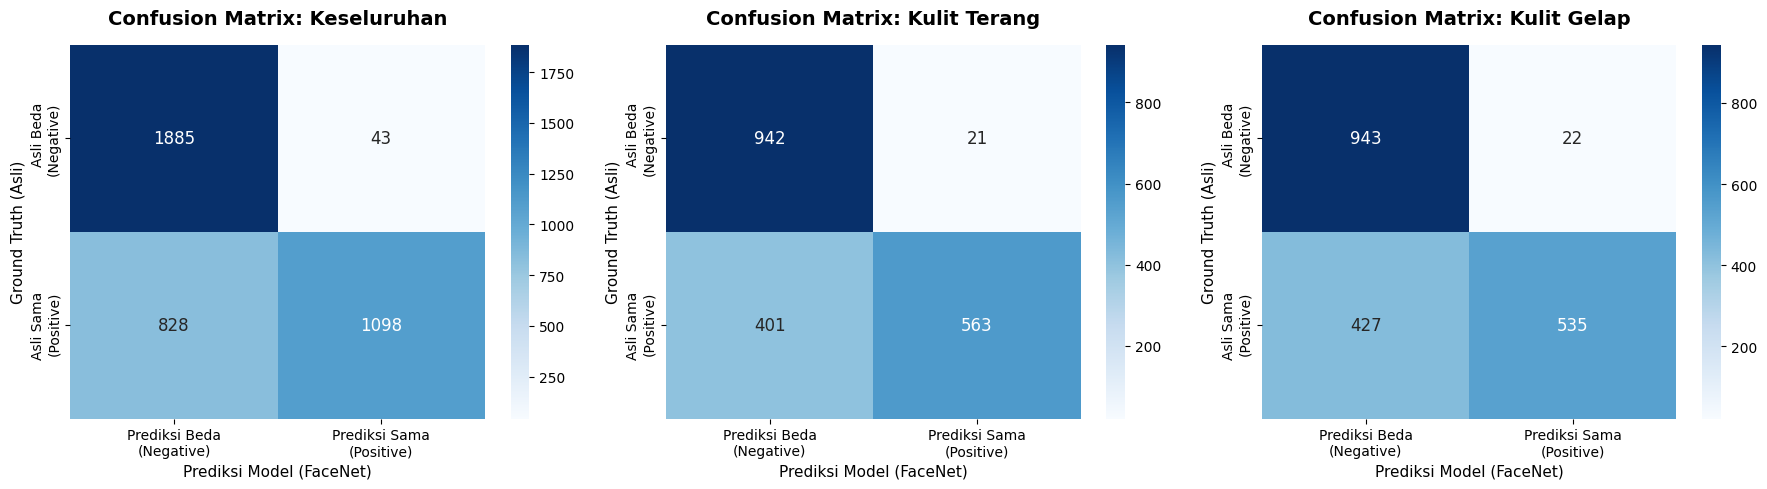

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ambil data yang berhasil dideteksi wajahnya saja
df_valid = df_pairs[df_pairs['Status_Biometrik'] == 'Success'].copy()

# Pastikan tipe data boolean untuk sklearn
df_valid['is_same'] = df_valid['is_same'].astype(bool)
df_valid['Prediksi_Sistem'] = df_valid['Prediksi_Sistem'].astype(bool)

def plot_confusion_matrix(df_subset, ax, title):
    y_true = df_subset['is_same']
    y_pred = df_subset['Prediksi_Sistem']

    # Label: [False, True] -> [Imposter/Beda, Genuine/Sama]
    cm = confusion_matrix(y_true, y_pred, labels=[False, True])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prediksi Beda\n(Negative)', 'Prediksi Sama\n(Positive)'],
                yticklabels=['Asli Beda\n(Negative)', 'Asli Sama\n(Positive)'],
                annot_kws={"size": 12})
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Prediksi Model (FaceNet)', fontsize=11)
    ax.set_ylabel('Ground Truth (Asli)', fontsize=11)

# Buat figure dengan 3 subplot berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Keseluruhan
plot_confusion_matrix(df_valid, axes[0], "Confusion Matrix: Keseluruhan")

# Plot Kulit Terang
df_terang = df_valid[df_valid['Kategori_Kulit_Pair'] == 'Terang']
plot_confusion_matrix(df_terang, axes[1], "Confusion Matrix: Kulit Terang")

# Plot Kulit Gelap
df_gelap = df_valid[df_valid['Kategori_Kulit_Pair'] == 'Gelap']
plot_confusion_matrix(df_gelap, axes[2], "Confusion Matrix: Kulit Gelap")

plt.tight_layout()
plt.show()

2. Plot Distribusi Jarak (Genuine vs Imposter)

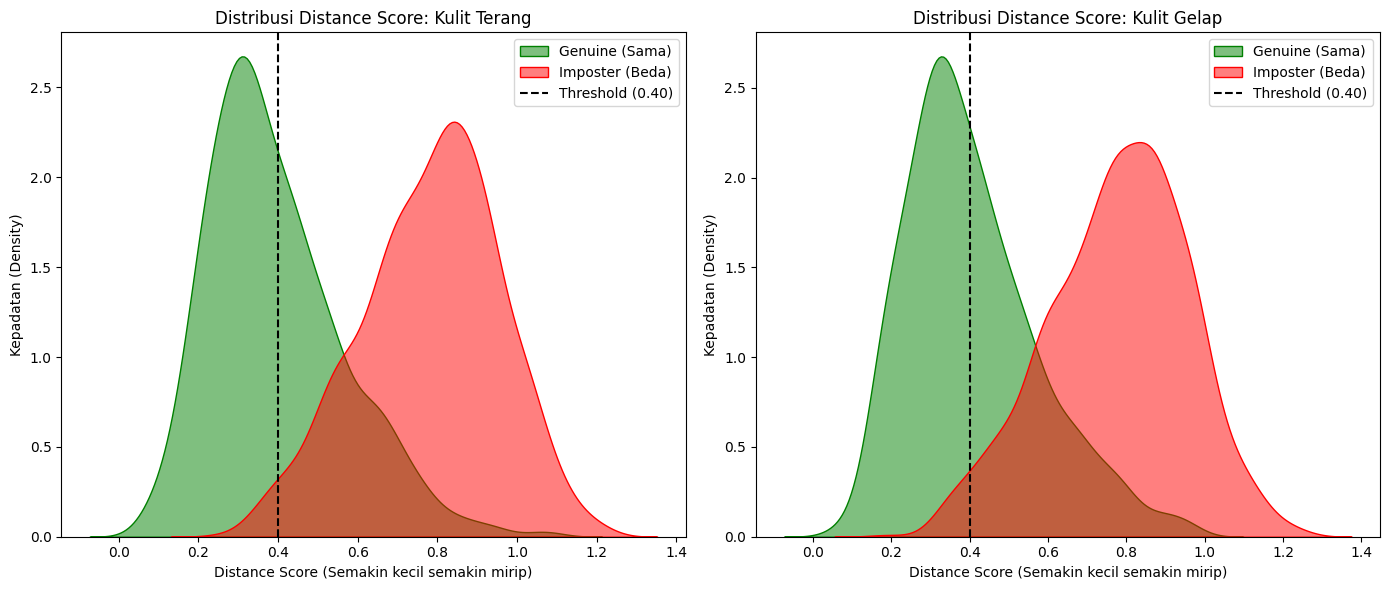

In [30]:
plt.figure(figsize=(14, 6))

# Plot untuk Kulit Terang
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_terang[df_terang['is_same'] == True]['Distance_Score'],
            label='Genuine (Sama)', fill=True, color='green', alpha=0.5)
sns.kdeplot(data=df_terang[df_terang['is_same'] == False]['Distance_Score'],
            label='Imposter (Beda)', fill=True, color='red', alpha=0.5)

# Threshold default FaceNet
plt.axvline(x=0.40, color='black', linestyle='--', label='Threshold (0.40)')

plt.title('Distribusi Distance Score: Kulit Terang', fontsize=12)
plt.xlabel('Distance Score (Semakin kecil semakin mirip)')
plt.ylabel('Kepadatan (Density)')
plt.legend()

# Plot untuk Kulit Gelap
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_gelap[df_gelap['is_same'] == True]['Distance_Score'],
            label='Genuine (Sama)', fill=True, color='green', alpha=0.5)
sns.kdeplot(data=df_gelap[df_gelap['is_same'] == False]['Distance_Score'],
            label='Imposter (Beda)', fill=True, color='red', alpha=0.5)

# Threshold default FaceNet
plt.axvline(x=0.40, color='black', linestyle='--', label='Threshold (0.40)')

plt.title('Distribusi Distance Score: Kulit Gelap', fontsize=12)
plt.xlabel('Distance Score (Semakin kecil semakin mirip)')
plt.ylabel('Kepadatan (Density)')
plt.legend()

plt.tight_layout()
plt.show()